In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# 여러 PyTorch transforms의 전처리 함수들을 순서대로 묶어 하나의 파이프라인으로 만든다.
# 아래 dataset에서 transform으로 지정하면, 파이프라인에 지정된 순서대로 변환된다.

transform = transforms.Compose([
    transforms.ToTensor(),  # PIL Image, Numpy array -> PyTorch Tensor
    transforms.Normalize((0.5,), (0.5,))  # (mean, std)를 인자로 받아 정규화, output = (input - mean) / std 
])

In [ ]:
# 

train_dataset = datasets.MNIST(
    root="./datasets/mnist",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./datasets/mnist",
    train=False,
    download=True,
    transform=transform
)

# batch_size를 지정하는 Mini-batch 방식을 통해 학습, shuffle로 매 epoch마다 학습 데이터를 무작위 배치
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [5]:
print(len(train_dataset))  
print(len(test_dataset))   

60000
10000


In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 64*7*7)
        return self.fc(x)

model = CNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007)

In [8]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

In [9]:
epochs = 10

for epoch in range(epochs):
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

     
  ## TESTING
    model.eval()
    correct_test = 0
    total_test = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct_test / total_test

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/10] Train Loss: 0.2493 | Test Loss: 0.0470 | Train Acc: 92.31% | Test Acc: 98.49%
Epoch [2/10] Train Loss: 0.0725 | Test Loss: 0.0392 | Train Acc: 97.83% | Test Acc: 98.73%
Epoch [3/10] Train Loss: 0.0528 | Test Loss: 0.0359 | Train Acc: 98.42% | Test Acc: 98.80%
Epoch [4/10] Train Loss: 0.0437 | Test Loss: 0.0271 | Train Acc: 98.64% | Test Acc: 99.10%
Epoch [5/10] Train Loss: 0.0355 | Test Loss: 0.0276 | Train Acc: 98.91% | Test Acc: 99.08%
Epoch [6/10] Train Loss: 0.0293 | Test Loss: 0.0243 | Train Acc: 99.04% | Test Acc: 99.16%
Epoch [7/10] Train Loss: 0.0267 | Test Loss: 0.0294 | Train Acc: 99.14% | Test Acc: 99.18%
Epoch [8/10] Train Loss: 0.0228 | Test Loss: 0.0235 | Train Acc: 99.28% | Test Acc: 99.20%
Epoch [9/10] Train Loss: 0.0192 | Test Loss: 0.0249 | Train Acc: 99.34% | Test Acc: 99.19%
Epoch [10/10] Train Loss: 0.0167 | Test Loss: 0.0255 | Train Acc: 99.46% | Test Acc: 99.32%


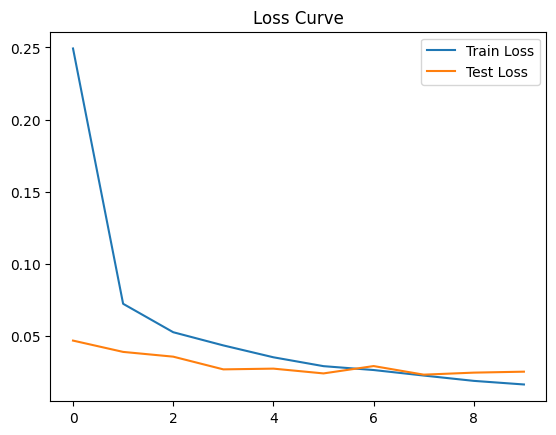

In [10]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

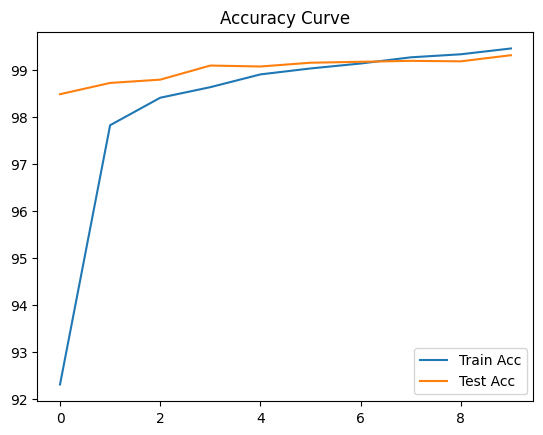

In [11]:
plt.figure()
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

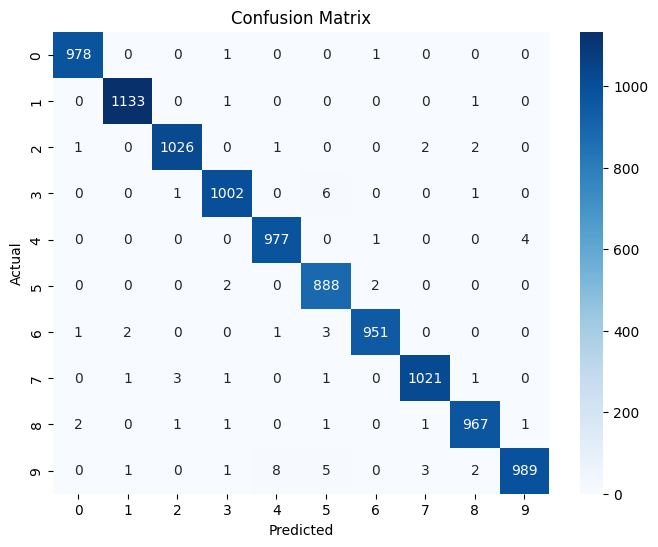

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

 
cm = confusion_matrix(all_labels, all_preds)

# 🔹 Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

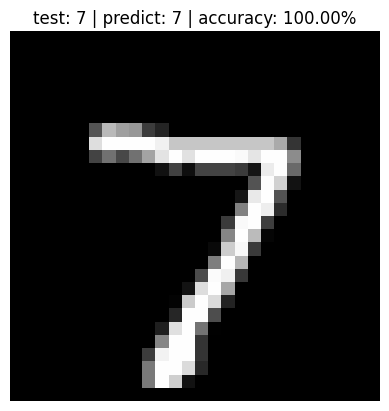

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

single_image = images[0].unsqueeze(0)
true_label = labels[0].item()

with torch.no_grad():
    output = model(single_image)
    
    probabilities = torch.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][predicted_label].item()

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"test: {true_label} | predict: {predicted_label} | accuracy: {confidence:.2%}")
plt.axis('off')
plt.show()